In [1]:
import numpy as np
population = np.random.rand(10,1000,5000)
print('population mean is : ',np.mean(population))

population mean is :  0.49998718187329083


In [2]:
population[0][0].ndim

1

In [20]:
# samples
sample_1 = np.random.choice(population[0][0],50)
sample_2 = np.random.choice(population[0][0],50)
sample_3 = np.random.choice(population[0][0],50)
print(np.mean(sample_1))
print(np.mean(sample_2))
print(np.mean(sample_3))

(np.mean(sample_1) + np.mean(sample_2) + np.mean(sample_3))/3

0.46819173370242045
0.48273959487483936
0.48537992767999455


np.float64(0.47877041875241816)

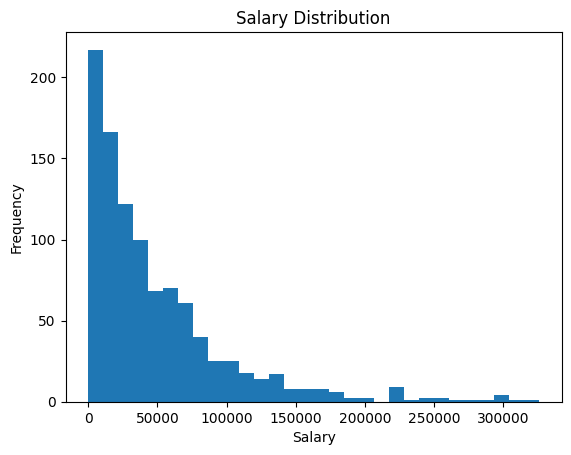

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# salary as a columns  : salary will look skewed data
salary = np.random.exponential(scale=50000, size=1000)
# print(salary(10))
plt.hist(salary, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

In [19]:
# salary mean
print('Salary Mean : ', np.mean(salary))

Salary Mean :  48372.51282047981


In [20]:
# samples from salary data
s1 = np.random.choice(salary, 50)
s2 = np.random.choice(salary, 50)
s3 = np.random.choice(salary, 50)

# compute the samples mean
avg_sample_mean = (np.mean(s1) + np.mean(s2) + np.mean(s3))/3
print('Average of Sample Means : ', avg_sample_mean)

Average of Sample Means :  49528.30241045199


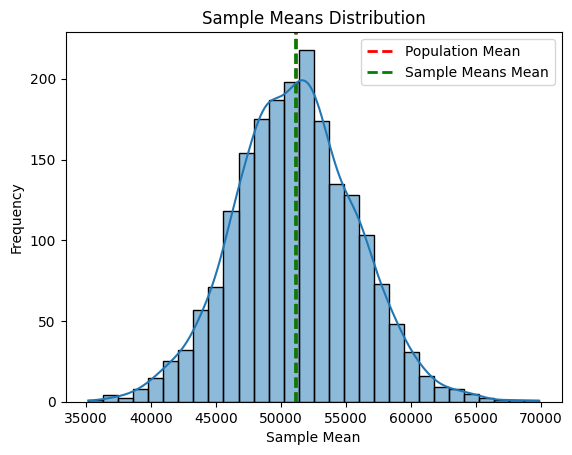

In [80]:
# lets plot the sample means distribution
sample_means = []
for _ in range(2000):
    sample = np.random.choice(salary, 120)
    sample_means.append(np.mean(sample))
# print(sample_means[:10])
# lets plot sample mean and population mean
plt.axvline(np.mean(salary), color='r', linestyle='dashed', linewidth=2, label='Population Mean')
plt.axvline(np.mean(sample_means), color='g', linestyle='dashed', linewidth=2, label='Sample Means Mean')
sns.histplot(sample_means, bins=30, kde=True)
plt.title('Sample Means Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# Basically in CLT, we are saying that
# No matter what the population distribution is,
#  the distribution of the sample means will be approximately normal
#  if the sample size is sufficiently large (usually n > 30).

# This is a powerful concept because it allows us to make inferences about population parameters
#  using the properties of the normal distribution, even when the population itself is not normally distributed

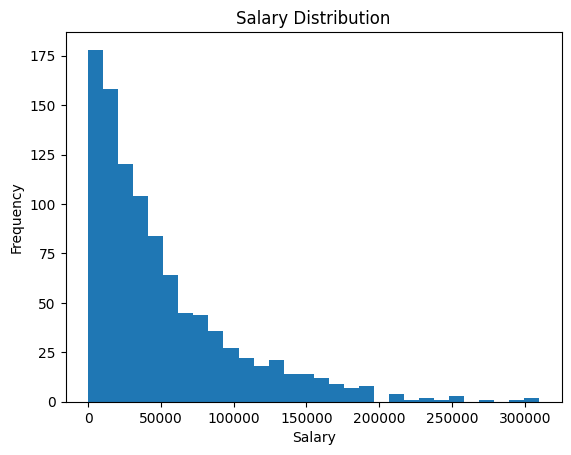

In [ ]:
salary = np.random.exponential(scale=50000, size=1000)
# scale is mean of the distribution, size is number of samples, exponential distribution is right skewed
plt.hist(salary, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

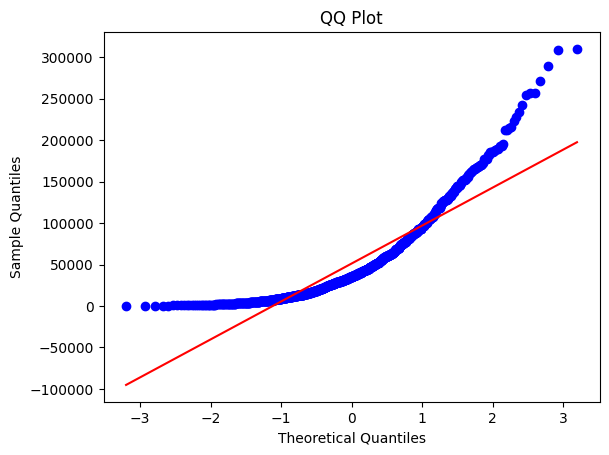

In [ ]:
# QQ plot
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(salary, dist="norm", plot=plt) # dist="norm" normal distribution
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

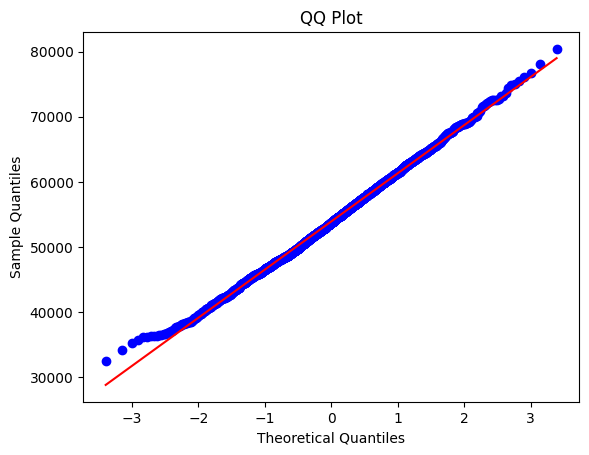

In [21]:
stats.probplot(sample_means, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

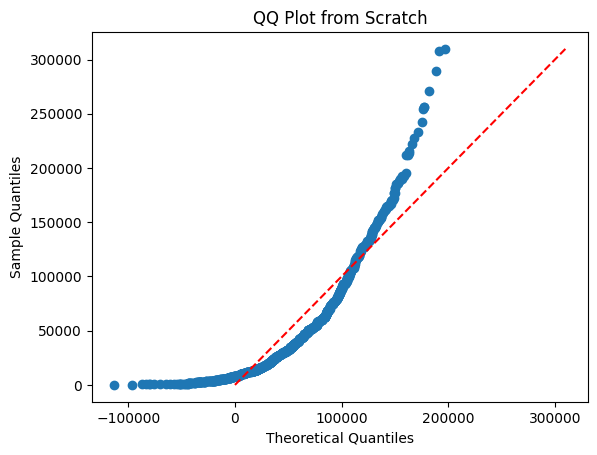

In [65]:
# Assignment  1 : Implement QQ plot from scratch
# Assignemnt  2 : Change mean to median in CLT example and observe the changes
import numpy as np
import matplotlib.pyplot as plt

# first sort the data
sorted_data = np.sort(salary)

# percentiles
n = len(sorted_data)
percentiles = (np.arange(1, n + 1) - 0.5) / n

# lets take normal distribution 
y = np.random.normal(loc=np.mean(salary), scale=np.std(salary), size=n)
# print(np.mean(salary), np.std(salary), np.mean(y), np.std(y))
y_sorted = np.sort(y)
# calculate the theoretical quantiles
theoretical_quantiles = np.percentile(y_sorted, percentiles * 100)
# 45 degree line
max_val = max(max(theoretical_quantiles), max(sorted_data))
plt.plot([0, max_val], [0, max_val], color='r', linestyle='--', label='45 Degree Line')
# plot the QQ plot
plt.scatter(theoretical_quantiles, sorted_data)
plt.title('QQ Plot from Scratch')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()  

### Refrence 
- https://www.freecodecamp.org/news/normal-distribution-explained/
- https://www.analyticsvidhya.com/blog/2019/05/statistics-101-introduction-central-limit-theorem/
- https://www.statlect.com/fundamentals-of-probability/Chebyshev-inequality

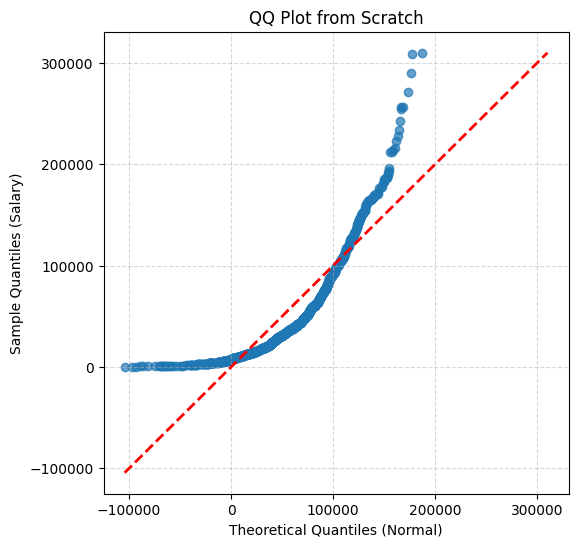

In [84]:
# Assignment  1 : Implement QQ plot from scratch

import numpy as np
import matplotlib.pyplot as plt

# first sort the data
sorted_data = np.sort(salary)

# percentiles
n = len(sorted_data)
percentiles = (np.arange(1, n + 1) - 0.5) / n

# lets take normal distribution 
y = np.random.normal(loc=np.mean(salary), scale=np.std(salary), size=n)
y_sorted = np.sort(y)

# calculate the theoretical quantiles
theoretical_quantiles = np.percentile(y_sorted, percentiles * 100)

# plot the QQ plot
plt.figure(figsize=(6, 6))
plt.scatter(theoretical_quantiles, sorted_data, alpha=0.7)

# 45 degree line
min_val = min(theoretical_quantiles[0], sorted_data[0])
max_val = max(theoretical_quantiles[-1], sorted_data[-1])
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles (Salary)')
plt.title('QQ Plot from Scratch')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


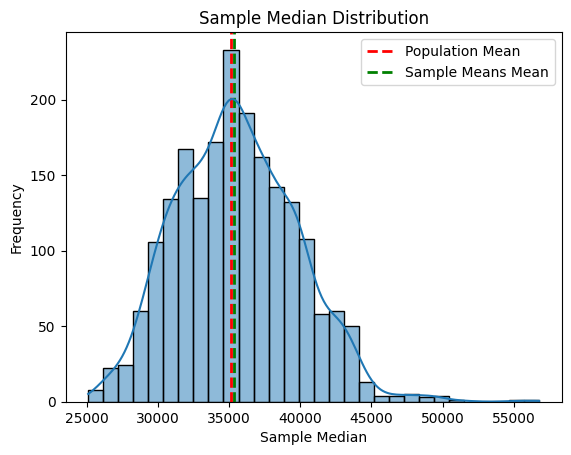

In [83]:
# Assignemnt  2 : Change mean to median in CLT example and observe the changes

sample_median = []
for _ in range(2000):
    sample = np.random.choice(salary, 120)
    sample_median.append(np.median(sample))

# lets plot sample mean and population mean
plt.axvline(np.median(salary), color='r', linestyle='dashed', linewidth=2, label='Population Mean')
plt.axvline(np.median(sample_median), color='g', linestyle='dashed', linewidth=2, label='Sample Means Mean')
sns.histplot(sample_median, bins=30, kde=True)
plt.title('Sample Median Distribution')
plt.xlabel('Sample Median')
plt.ylabel('Frequency')
plt.legend()
plt.show()